<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [ ]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_ROOT = Path('/content/latent-ability-ml')
    if not REPO_ROOT.exists():
        subprocess.check_call([
            'git',
            'clone',
            'https://github.com/manuelfjr/latent-ability-ml.git',
            str(REPO_ROOT),
        ])

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'numpy',
        'pandas',
        'matplotlib',
        'scipy',
        'scikit-learn',
        'seaborn',
        'joblib',
        'tqdm',
        'birt-gd',
    ])

    for candidate in [REPO_ROOT, REPO_ROOT / 'notebooks', REPO_ROOT / 'utils', REPO_ROOT / 'src']:
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)

    from nb_utils import set_root
    PROJECT_ROOT = REPO_ROOT
    print(f'Running in Colab with project root: {PROJECT_ROOT}')
else:
    from nb_utils import set_root
    PROJECT_ROOT = set_root(level=2)
    print(f'Running locally with project root: {PROJECT_ROOT}')


**Environment note.** Run the next code cell first. It loads the repository and the local modules needed for this notebook, especially when opening it in Google Colab.


# Answer 3: Beta4-IRT on a Synthetic Response Matrix

This notebook provides one worked solution path for the Section 3 activity.


## Activity Goals

By the end of this notebook, you should be able to:

- simulate a bounded response matrix with medium to high variability;
- fit Beta4-IRT on synthetic data;
- inspect estimated abilities, difficulties, and discriminations;
- discuss what the latent parameters say about the response structure.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from birt import Beta4

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering, MeanShift, OPTICS
from sklearn.metrics import (
    adjusted_rand_score,
    mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
)

from utils.transform import TransformPairwise
from utils.handson import beta4_expected_response


## Task 1: Generate a synthetic dataset with medium to high variability

Build a dataset with enough heterogeneity to make clustering nontrivial.

Suggestions:

- use `make_blobs`; 
- choose at least 3 centers;
- use different `cluster_std` values;
- keep one group more dispersed than the others.

If you prefer, you may replace this with another synthetic dataset of your choice.


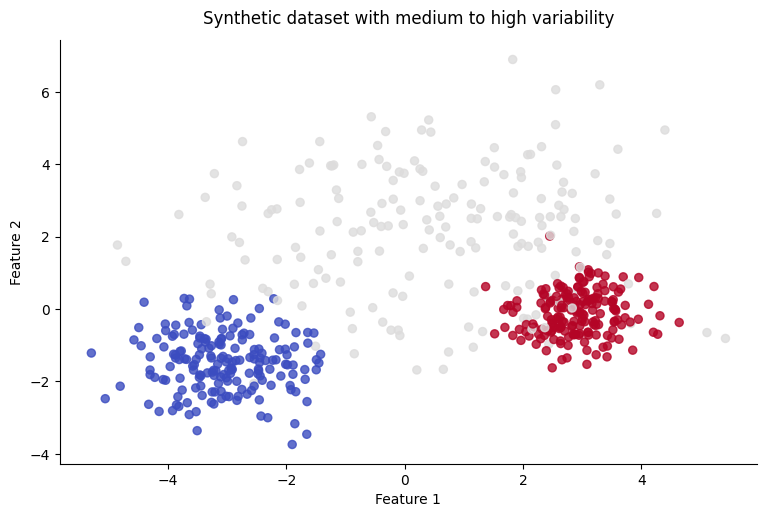

,feature_1,feature_2,label,instance_id
0,-3.494581,-0.960071,0,0
1,2.982257,0.488217,2,1
2,1.973279,3.630775,1,2
3,-1.141483,2.412145,1,3
4,-3.524170,-1.393768,0,4


In [3]:
X, y = make_blobs(
    n_samples=540,
    centers=[[-3.0, -1.5], [0.5, 2.0], [3.0, -0.2]],
    cluster_std=[0.8, 1.9, 0.55],
    random_state=24,
)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['label'] = y
df['instance_id'] = np.arange(len(df))

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.scatter(df['feature_1'], df['feature_2'], c=df['label'], cmap='coolwarm', alpha=0.8, s=34)
ax.set_title('Synthetic dataset with medium to high variability', pad=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

df.head()


## Task 2: Train a pool of clustering models

Create a model pool with different inductive biases. The disagreement between these models is what will later define the CLAIRE response matrix.


In [4]:
models = {
    **{f'KMeans_k_{k}': KMeans(n_clusters=k, random_state=1, n_init=20) for k in range(2, 6)},
    **{f'DBSCAN_eps_{eps:.2f}': DBSCAN(eps=float(eps), min_samples=6) for eps in [0.25, 0.45, 0.70, 0.95]},
    **{f'Spectral_k_{k}': SpectralClustering(n_clusters=k, random_state=1, assign_labels='kmeans') for k in range(2, 6)},
    'MeanShift': MeanShift(),
    'OPTICS_min_samples_6': OPTICS(min_samples=6),
}

results = []
partitions = pd.DataFrame(index=df['instance_id'], columns=models.keys())

for key, model in models.items():
    labels_pred = model.fit_predict(df[['feature_1', 'feature_2']].values)
    partitions[key] = labels_pred
    metrics = {
        'model': key,
        'adjusted_rand_score': adjusted_rand_score(df['label'], labels_pred),
        'mutual_info_score': mutual_info_score(df['label'], labels_pred),
    }
    try:
        metrics |= {
            'silhouette_score': silhouette_score(df[['feature_1', 'feature_2']], labels_pred),
            'calinski_harabasz_score': calinski_harabasz_score(df[['feature_1', 'feature_2']], labels_pred),
        }
    except Exception:
        metrics |= {
            'silhouette_score': np.nan,
            'calinski_harabasz_score': np.nan,
        }
    results.append(metrics)

results = pd.DataFrame(results).sort_values('adjusted_rand_score', ascending=False)
results


,model,adjusted_rand_score,mutual_info_score,silhouette_score,calinski_harabasz_score
12,MeanShift,0.699369,0.762565,0.605148,1172.847203
5,DBSCAN_eps_0.45,0.691459,0.837519,0.246429,183.580695
2,KMeans_k_4,0.684927,0.820020,0.573036,1096.975599
9,Spectral_k_3,0.681378,0.754576,0.609676,1165.253068
1,KMeans_k_3,0.677066,0.749585,0.609913,1183.211363
3,KMeans_k_5,0.652647,0.850570,0.495237,991.286815
8,Spectral_k_2,0.497138,0.513891,0.584281,913.502878
0,KMeans_k_2,0.478761,0.494654,0.590767,969.099526
4,DBSCAN_eps_0.25,0.475955,0.567615,0.245861,235.662415
10,Spectral_k_4,0.183702,0.320607,0.138243,69.857956


## Task 3: Generate the response matrix `pij`

Use the agreement between the clustering models to construct the response matrix used by CLAIRE.


In [5]:
# The CLAIRE response matrix must be built from pairwise agreement, so we use TransformPairwise.
tp = TransformPairwise(1)
pij = tp.generate_pij_matrix(partitions)

print(pij.shape)
pij.head()


100%|██████████| 540/540 [00:00<00:00, 996.66it/s] 

(540, 14)


,KMeans_k_2,KMeans_k_3,KMeans_k_4,KMeans_k_5,DBSCAN_eps_0.25,DBSCAN_eps_0.45,DBSCAN_eps_0.70,DBSCAN_eps_0.95,Spectral_k_2,Spectral_k_3,Spectral_k_4,Spectral_k_5,MeanShift,OPTICS_min_samples_6
0,0.765663,0.783074,0.783930,0.751962,0.673469,0.760525,0.475953,0.442557,0.780791,0.784787,0.601827,0.594406,0.781932,0.521336
1,0.699158,0.767090,0.765663,0.763665,0.706579,0.749108,0.565006,0.546739,0.688312,0.766234,0.630084,0.630084,0.766234,0.512488
2,0.570144,0.688883,0.670044,0.658913,0.610104,0.622378,0.343228,0.349793,0.572428,0.682318,0.662909,0.663765,0.697160,0.482232
3,0.541459,0.685315,0.651349,0.651920,0.603967,0.637648,0.325103,0.343085,0.555159,0.684744,0.648780,0.602255,0.684173,0.490081
4,0.764664,0.782075,0.782931,0.750963,0.672470,0.759526,0.474954,0.441558,0.779792,0.783788,0.600828,0.593407,0.780933,0.508349


## Task 4: Train Beta4-IRT

Fit Beta4 on the response matrix and inspect the estimated abilities of the models.


In [6]:
birt = Beta4(
    learning_rate=1,
    epochs=10_000,
    n_respondents=pij.shape[1],
    n_items=pij.shape[0],
    n_inits=1000,
    n_workers=1,
    random_seed=1,
    tol=10**(-8),
    set_priors=True,
)

birt.fit(pij.values)

abilities = pd.DataFrame(
    {
        'model': partitions.columns,
        'ability': birt.abilities,
    }
).sort_values('ability', ascending=False)

abilities


 39%|███▉      | 3893/10000 [00:08<00:13, 465.47it/s]


Model converged at the 3893th epoch


,model,ability
12,MeanShift,0.528894
1,KMeans_k_3,0.528879
9,Spectral_k_3,0.527883
2,KMeans_k_4,0.524704
3,KMeans_k_5,0.505809
5,DBSCAN_eps_0.45,0.498137
8,Spectral_k_2,0.483643
0,KMeans_k_2,0.483198
4,DBSCAN_eps_0.25,0.440376
10,Spectral_k_4,0.432579


## Task 5: Compare abilities with standard clustering metrics

Merge the estimated abilities with standard clustering metrics and inspect how the rankings compare.
